# 6주차: 논문 구현

## 금주 학습목표
* 논문 구현
    * Data Scraping
    * Generation of training sets

## 1. 데이터 확보

주식 상위 30개 코인 상위 10개 데이터 다운로드 및 정제

In [1]:
import yfinance as yf
import pandas as pd

sp500_tickers = [
    'NVDA', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK-B',
    'WMT', 'LLY', 'JPM', 'XOM', 'JNJ', 'V', 'COST', 'MA', 'ORCL', 'NFLX',
    'MU', 'CVX', 'ABBV', 'PLTR', 'AMD', 'BAC', 'CAT', 'PG', 'KO', 'HD'
]

crypto_tickers = [
    'BTC-USD', 'ETH-USD', 'USDT-USD', 'XRP-USD', 'BNB-USD',
    'USDC-USD', 'SOL-USD', 'TRX-USD', 'DOGE-USD', 'HYPE-USD'
]

tickers = sp500_tickers + crypto_tickers

stock_data = yf.download(sp500_tickers, period='5y', interval='1d', auto_adjust=True)
crypto_data = yf.download(crypto_tickers, period='5y', interval='1d', auto_adjust=True)
data = pd.concat([stock_data, crypto_data], axis = 1)

[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  10 of 10 completed
C:\Users\skack\AppData\Local\Temp\ipykernel_29536\4206629555.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat([stock_data, crypto_data], axis = 1)


In [2]:
print("="*10,"data 형태 (행, 열):","="*10)
print(data.shape)
print("="*10,"columns","="*10)
print(data.columns[0:5])
print("="*10,"head","="*10)
print(data.head())


========== data 형태 (행, 열): ==========
(1828, 200)
========== columns ==========
MultiIndex([('Close', 'AAPL'),
            ('Close', 'ABBV'),
            ('Close',  'AMD'),
            ('Close', 'AMZN'),
            ('Close', 'AVGO')],
           names=['Price', 'Ticker'])
========== head ==========
Price            Close                                               \
Ticker            AAPL       ABBV        AMD        AMZN       AVGO   
Date                                                                  
2021-04-05  122.626053  87.656662  81.430000  161.336502  44.194817   
2021-04-06  122.927994  87.029015  81.440002  161.190994  43.777733   
2021-04-07  124.574028  86.888611  82.199997  163.969498  43.650162   
2021-04-08  126.970070  87.623642  83.349998  164.964996  43.923386   
2021-04-09  129.541428  88.812874  82.760002  168.610001  43.888107   

Price                                                                 ...  \
Ticker            BAC       BRK-B         CAT        

In [3]:
stock_close = stock_data['Close']
crypto_close = crypto_data['Close']
data_close = data['Close']

In [4]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close.shape)
print("="*10,"columns","="*10)
print(data_close.columns[0:5])
print("="*10,"head","="*10)
print(data_close.head())
print("="*10,"결측 0나와야함","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1828, 40)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO'], dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-05  122.626053  87.656662  81.430000  161.336502  44.194817   
2021-04-06  122.927994  87.029015  81.440002  161.190994  43.777733   
2021-04-07  124.574028  86.888611  82.199997  163.969498  43.650162   
2021-04-08  126.970070  87.623642  83.349998  164.964996  43.923386   
2021-04-09  129.541428  88.812874  82.760002  168.610001  43.888107   

Ticker            BAC       BRK-B         CAT        COST        CVX  ...  \
Date                                                                  ...   
2021-04-05  35.248104  262.660004  213.145721  341.606415  84.866341  ...   
2021-04-06  35.150684  263.059998  210.345871  340.943695  84.111160  ...   
2021-04-

In [5]:
crypto_close.isnull().cumsum()

Ticker,BNB-USD,BTC-USD,DOGE-USD,ETH-USD,HYPE-USD,SOL-USD,TRX-USD,USDC-USD,USDT-USD,XRP-USD
Date,,,,,,,,,,
2021-04-06,0,0,0,0,0,0,0,0,0,0
2021-04-07,0,0,0,0,0,0,0,0,0,0
2021-04-08,0,0,0,0,0,0,0,0,0,0
2021-04-09,0,0,0,0,0,0,0,0,0,0
2021-04-10,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2026-04-02,0,0,0,0,583,0,0,0,0,0
2026-04-03,0,0,0,0,584,0,0,0,0,0
2026-04-04,0,0,0,0,585,0,0,0,0,0


In [6]:
crypto_close['HYPE-USD'] #상폐 안됐는데 왜 없음...?

Date
2021-04-06    3.471945
2021-04-07    3.440510
2021-04-08    2.892028
2021-04-09    2.885778
2021-04-10    2.747460
                ...   
2026-04-02         NaN
2026-04-03         NaN
2026-04-04         NaN
2026-04-05         NaN
2026-04-06         NaN
Freq: D, Name: HYPE-USD, Length: 1827, dtype: float64

In [7]:
stock_close['AAPL'].head(10)

Date
2021-04-05    122.626053
2021-04-06    122.927994
2021-04-07    124.574028
2021-04-08    126.970070
2021-04-09    129.541428
2021-04-12    127.827179
2021-04-13    130.934189
2021-04-14    128.596634
2021-04-15    131.002396
2021-04-16    130.671280
Name: AAPL, dtype: float64

In [8]:
data_close['AAPL'].isnull().head(30)

Date
2021-04-05    False
2021-04-06    False
2021-04-07    False
2021-04-08    False
2021-04-09    False
2021-04-10     True
2021-04-11     True
2021-04-12    False
2021-04-13    False
2021-04-14    False
2021-04-15    False
2021-04-16    False
2021-04-17     True
2021-04-18     True
2021-04-19    False
2021-04-20    False
2021-04-21    False
2021-04-22    False
2021-04-23    False
2021-04-24     True
2021-04-25     True
2021-04-26    False
2021-04-27    False
2021-04-28    False
2021-04-29    False
2021-04-30    False
2021-05-01     True
2021-05-02     True
2021-05-03    False
2021-05-04    False
Freq: D, Name: AAPL, dtype: bool

In [9]:
# stock_close = stock_close.ffill().bfill()
crypto_close = crypto_close.drop(columns=['HYPE-USD'])
data_close = data_close.drop(columns=['HYPE-USD'])
data_close = data_close.ffill().bfill()

In [10]:
print("="*10,"data_close 형태 (행, 열)","="*10)
print(data_close.shape)
print("="*10,"columns","="*10)
print(data_close.columns)
print("="*10,"head","="*10)
print(data_close.head())
print("="*10,"결측","="*10)
print("주식:",stock_close.isnull().sum().max())
print("코인:",crypto_close.isnull().sum().max())
print("전체:",data_close.isnull().sum().max())

========== data_close 형태 (행, 열) ==========
(1828, 39)
========== columns ==========
Index(['AAPL', 'ABBV', 'AMD', 'AMZN', 'AVGO', 'BAC', 'BRK-B', 'CAT', 'COST',
       'CVX', 'GOOG', 'GOOGL', 'HD', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 'META',
       'MSFT', 'MU', 'NFLX', 'NVDA', 'ORCL', 'PG', 'PLTR', 'TSLA', 'V', 'WMT',
       'XOM', 'BNB-USD', 'BTC-USD', 'DOGE-USD', 'ETH-USD', 'SOL-USD',
       'TRX-USD', 'USDC-USD', 'USDT-USD', 'XRP-USD'],
      dtype='str', name='Ticker')
========== head ==========
Ticker            AAPL       ABBV        AMD        AMZN       AVGO  \
Date                                                                  
2021-04-05  122.626053  87.656662  81.430000  161.336502  44.194817   
2021-04-06  122.927994  87.029015  81.440002  161.190994  43.777733   
2021-04-07  124.574028  86.888611  82.199997  163.969498  43.650162   
2021-04-08  126.970070  87.623642  83.349998  164.964996  43.923386   
2021-04-09  129.541428  88.812874  82.760002  168.610001  43.888107   


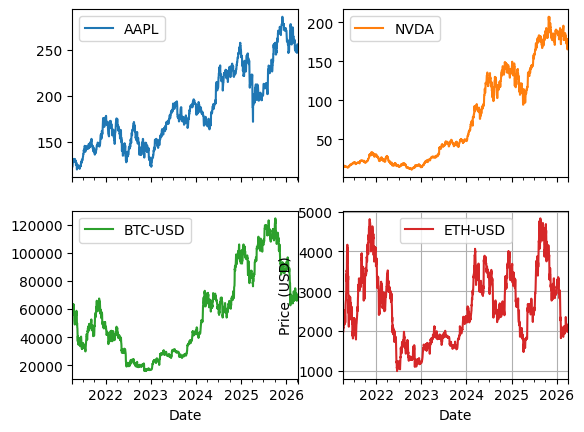

In [11]:
import matplotlib.pyplot as plt

data_close[['AAPL','NVDA','BTC-USD','ETH-USD']].plot.line(subplots=True, layout = (2,2))
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

In [12]:
returns = data_close.pct_change()
stock_returns = stock_close.pct_change()
crypto_returns = crypto_close.pct_change()

returns = returns.dropna()
stock_returns = stock_close.dropna()
crypto_returns = crypto_close.dropna()

print(returns.head())

Ticker          AAPL      ABBV       AMD      AMZN      AVGO       BAC  \
Date                                                                     
2021-04-06  0.002462 -0.007160  0.000123 -0.000902 -0.009437 -0.002764   
2021-04-07  0.013390 -0.001613  0.009332  0.017237 -0.002914  0.009070   
2021-04-08  0.019234  0.008459  0.013990  0.006071  0.006259 -0.008739   
2021-04-09  0.020252  0.013572 -0.007079  0.022096 -0.000803  0.007305   
2021-04-10  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

Ticker         BRK-B       CAT      COST       CVX  ...       XOM   BNB-USD  \
Date                                                ...                       
2021-04-06  0.001523 -0.013136 -0.001940 -0.008898  ... -0.002832  0.000000   
2021-04-07  0.002129 -0.000997 -0.003638  0.005889  ...  0.004438 -0.071686   
2021-04-08 -0.000417  0.000304  0.006717 -0.011230  ... -0.010426  0.115784   
2021-04-09  0.009487  0.001171  0.005509 -0.000970  ... -0.002321  0.084059   
2021-04